# Gothic Terrain DEM

Download a USGS 3DEP DEM for the Gothic area and plot terrain for `-107.2` to `-106.8` longitude and `38.75` to `39.15` latitude.

Using cached DEM: /glade/u/home/cdalden/goes_work/analysis/data/dem_gothic_box/usgs_3dep_dem_gothic_box.tif


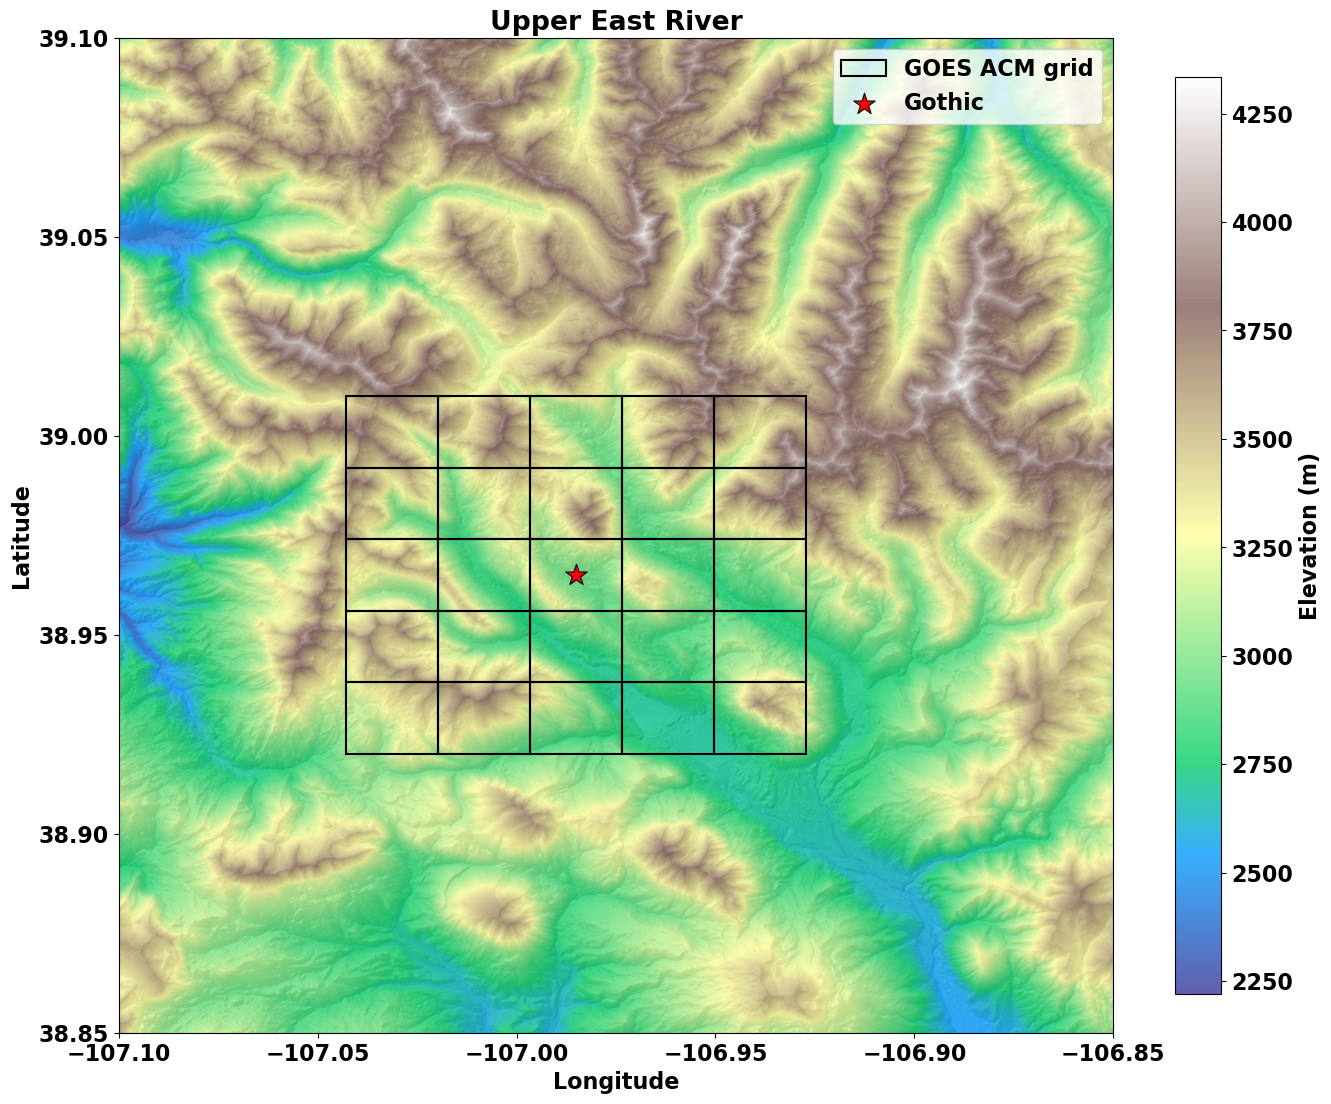

In [7]:
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
from matplotlib.patches import Rectangle
from PIL import Image

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False
plt.rcParams["font.size"] = 16
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

WEST, EAST = -107.1, -106.85
SOUTH, NORTH = 38.85, 39.1
BOUNDS = (WEST, SOUTH, EAST, NORTH)
BOX_WEST, BOX_EAST = -107.05, -106.92
BOX_SOUTH, BOX_NORTH = 38.90, 39.03

DEM_DIR = Path("/glade/u/home/cdalden/goes_work/analysis/data/dem_gothic_box")
DEM_DIR.mkdir(parents=True, exist_ok=True)
DEM_TIF = DEM_DIR / "usgs_3dep_dem_gothic_box.tif"


def download_usgs_3dep_dem(bounds, out_path, pixels=1200):
    """Download a cropped USGS 3DEP DEM image for a lon/lat bounding box."""
    if out_path.exists():
        print(f"Using cached DEM: {out_path}")
        return out_path

    west, south, east, north = bounds
    url = "https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer/exportImage"
    params = {
        "bbox": f"{west},{south},{east},{north}",
        "bboxSR": 4326,
        "imageSR": 4326,
        "size": f"{pixels},{pixels}",
        "format": "tiff",
        "pixelType": "F32",
        "noDataInterpretation": "esriNoDataMatchAny",
        "interpolation": "+RSP_BilinearInterpolation",
        "f": "image",
    }
    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()
    out_path.write_bytes(response.content)
    print(f"Downloaded DEM: {out_path}")
    return out_path


def hillshade(elevation, azimuth=315, altitude=45):
    """Simple hillshade for visual terrain relief."""
    filled = np.nan_to_num(elevation, nan=np.nanmedian(elevation))
    dy, dx = np.gradient(filled)
    slope = np.pi / 2 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)
    azimuth_rad = np.deg2rad(azimuth)
    altitude_rad = np.deg2rad(altitude)
    shaded = (
        np.sin(altitude_rad) * np.sin(slope)
        + np.cos(altitude_rad) * np.cos(slope) * np.cos(azimuth_rad - aspect)
    )
    return np.clip((shaded + 1) / 2, 0, 1)


dem_path = download_usgs_3dep_dem(BOUNDS, DEM_TIF)

with Image.open(dem_path) as img:
    elevation = np.array(img, dtype=float)

elevation[elevation < -1000] = np.nan
extent = (WEST, EAST, SOUTH, NORTH)
shade = hillshade(elevation)

fig, ax = plt.subplots(figsize=(14, 12))
ax.imshow(shade, cmap="gray", extent=extent, origin="upper", alpha=0.55)
im = ax.imshow(elevation, cmap="terrain", extent=extent, origin="upper", alpha=0.78)
ax.set_xlim(WEST, EAST)
ax.set_ylim(SOUTH, NORTH)
gothic_lon = (BOX_WEST + BOX_EAST) / 2
gothic_lat = (BOX_SOUTH + BOX_NORTH) / 2

# Draw one 5 x 5 grid of 2 km x 2 km cells centered on Gothic.
km_per_degree_lat = 111.32
cell_height = 2.0 / km_per_degree_lat
cell_width = 2.0 / (km_per_degree_lat * np.cos(np.deg2rad(gothic_lat)))
grid_west = gothic_lon - 2.5 * cell_width
grid_south = gothic_lat - 2.5 * cell_height
grid_handle = None
for row in range(5):
    for col in range(5):
        cell = Rectangle(
            (grid_west + col * cell_width, grid_south + row * cell_height),
            cell_width,
            cell_height,
            fill=False,
            edgecolor="black",
            linewidth=1.5,
            label="GOES ACM grid" if grid_handle is None else None,
            zorder=5,
        )
        ax.add_patch(cell)
        if grid_handle is None:
            grid_handle = cell

gothic_marker = ax.scatter(
    gothic_lon,
    gothic_lat,
    marker="*",
    s=260,
    color="red",
    edgecolor="black",
    linewidth=0.8,
    label="Gothic",
    zorder=6,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Upper East River")
ax.legend(handles=[grid_handle, gothic_marker], loc="upper right")
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("Elevation (m)")
plt.tight_layout()


## Western U.S. evaluation sites

Terrain context and locations of the four model-training/evaluation sites.

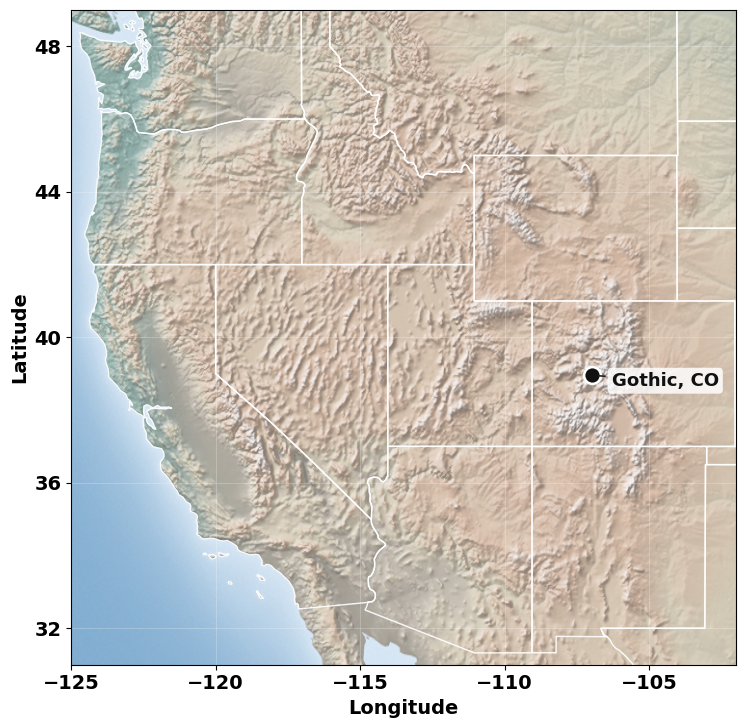

Saved map to /glade/u/home/cdalden/goes_work/analysis/output_16_western_us_site_map.png


In [8]:
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
from shapely.geometry import box

MAP_WEST, MAP_EAST = -125.0, -102.0
MAP_SOUTH, MAP_NORTH = 31.0, 49.0
NATURAL_EARTH_DIR = Path("analysis/data/natural_earth")
if not NATURAL_EARTH_DIR.exists():
    NATURAL_EARTH_DIR = Path("data/natural_earth")

RELIEF_TIF = NATURAL_EARTH_DIR / "HYP_50M_SR_W.tif"
STATES_SHP = NATURAL_EARTH_DIR / "ne_50m_admin_1_states_provinces.shp"
ANALYSIS_DIR = (
    Path.cwd()
    if (Path.cwd() / "data" / "natural_earth").exists()
    else Path.cwd() / "analysis"
)
MAP_OUTPUT = ANALYSIS_DIR / "output_16_western_us_site_map.png"

sites = {
    "Gothic, CO": (-106.9886, 38.9580),
    # "Table Mountain, CO": (-105.21, 39.78),
    # "Senator Beck, CO": (-107.7200, 37.9000),
    # "Jeff Dozier Site/Mammoth, CA": (-119.0290, 37.6430),
}
site_colors = {
    name: ("#111111" if name == "Gothic, CO" else "#D73027")
    for name in sites
}
label_offsets = {
    "Gothic, CO": (0.7, -0.15),
    "Table Mountain, CO": (-3.8, 0.65),
    "Senator Beck, CO": (-3.1, -1.0),
    "Jeff Dozier Site/Mammoth, CA": (0.7, 0.55),
}

with rasterio.open(RELIEF_TIF) as src:
    window = from_bounds(
        MAP_WEST, MAP_SOUTH, MAP_EAST, MAP_NORTH, transform=src.transform
    ).round_offsets().round_lengths()
    relief = np.moveaxis(src.read(window=window), 0, -1)
    left, bottom, right, top = rasterio.windows.bounds(window, src.transform)
    relief_extent = (left, right, bottom, top)

states = gpd.read_file(STATES_SHP)
western_box = box(MAP_WEST, MAP_SOUTH, MAP_EAST, MAP_NORTH)
western_states = states.loc[
    (states.iso_a2 == "US") & states.geometry.intersects(western_box)
]

with plt.rc_context({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
}):
    fig, ax = plt.subplots(figsize=(10.5, 7.5))
    ax.imshow(
        relief,
        extent=relief_extent,
        origin="upper",
        interpolation="bilinear",
        alpha=0.92,
        zorder=0,
    )
    western_states.boundary.plot(
        ax=ax, color="white", linewidth=1.05, alpha=0.9, zorder=2
    )

    for name, (lon, lat) in sites.items():
        ax.scatter(
            lon, lat, s=145, marker="o", color=site_colors[name],
            edgecolor="white", linewidth=1.8, zorder=5,
        )
        dx, dy = label_offsets[name]
        ax.annotate(
            name,
            xy=(lon, lat),
            xytext=(lon + dx, lat + dy),
            textcoords="data",
            ha="left",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="#111111",
            bbox=dict(
                boxstyle="round,pad=0.22",
                facecolor="white",
                edgecolor="none",
                alpha=0.84,
            ),
            arrowprops=dict(
                arrowstyle="-", color="#222222", linewidth=1.2,
                shrinkA=2, shrinkB=5,
            ),
            zorder=6,
        )

    ax.set_xlim(MAP_WEST, MAP_EAST)
    ax.set_ylim(MAP_SOUTH, MAP_NORTH)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xticks(np.arange(-125, -101, 5))
    ax.set_yticks(np.arange(32, 50, 4))
    ax.grid(color="white", alpha=0.22, linewidth=0.8)
    for label in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        label.set_fontweight("bold")
    fig.tight_layout()
    fig.savefig(MAP_OUTPUT, dpi=300, bbox_inches="tight")
    plt.show()

print(f"Saved map to {MAP_OUTPUT.resolve()}")